# Classification Track — Insurance Claims Fraud Detection
**23CSE301 Machine Learning Capstone — Review 1 (Part A)**

**Dataset:** `data/insurance_claims/insurance_claims.csv` (1,000 rows x 40 columns) — auto-insurance policy and incident records.

**Problem statement:** Predict **`fraud_reported`** (Yes/No) — whether an insurance claim is fraudulent — from policy, customer and incident attributes.

**Scope of this notebook (Review 1, Part A):**

1. Data loading & audit
2. Exploratory Data Analysis (EDA)
3. Data cleaning, feature engineering, encoding, scaling, splitting.
4. **Dimensionality reduction (PCA)** — fit on the training split, then used as the shared preprocessing for every Part-A algorithm.
5. Training & evaluating **Part-A algorithms** on the PCA-reduced features:
    - Logistic Regression
    -  K-Nearest Neighbors
    -  Naive Bayes (Gaussian)
    -  Decision Tree Classifier
    -  Support Vector Machine (SVC)
7. Preliminary comparison table
   - Accuracy
   - weighted F1
   - confusion matrix)
   
**Part B** (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the final 10-algorithm consolidated comparison .

**Random seed** `42` is used everywhere for reproducibility.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/insurance_claims/insurance_claims.csv'

## Section A — Dataset Loading & Audit (A1)

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
print('Data types:')
print(df.dtypes.value_counts())

Shape: 1000 rows x 40 columns

Data types:
object     21
int64      17
float64     2
Name: count, dtype: int64


In [3]:
# The raw CSV encodes missing categorical values as the literal string '?'; convert to NaN
# so pandas/sklearn treat them as proper missing values.
df = df.replace('?', np.nan)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing)

print(f'\nDuplicate rows: {df.duplicated().sum()}')

print('\nTarget (fraud_reported) class distribution:')
print(df['fraud_reported'].value_counts())
print(df['fraud_reported'].value_counts(normalize=True).round(3))

Columns with missing values:
_c39                       1000
property_damage             360
police_report_available     343
collision_type              178
authorities_contacted        91
dtype: int64

Duplicate rows: 0

Target (fraud_reported) class distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64
fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64


**Observation:** The dataset has 1,000 rows and 40 columns. `_c39` is a completely empty stray column (an artifact of the CSV export) and will be dropped. Four genuine categorical columns — `collision_type`, `property_damage`, `police_report_available`, `authorities_contacted` — have missing values that were originally encoded as `'?'`. There are no duplicate rows. The target `fraud_reported` is **imbalanced** (~75% "N" / ~25% "Y"), so a stratified split and weighted/F1-based metrics (rather than accuracy alone) are used throughout.

## Section A — EDA Visualisations (A2)

### A2.1 Distribution of every numeric feature

16 numeric columns plotted, 17 categorical columns plotted


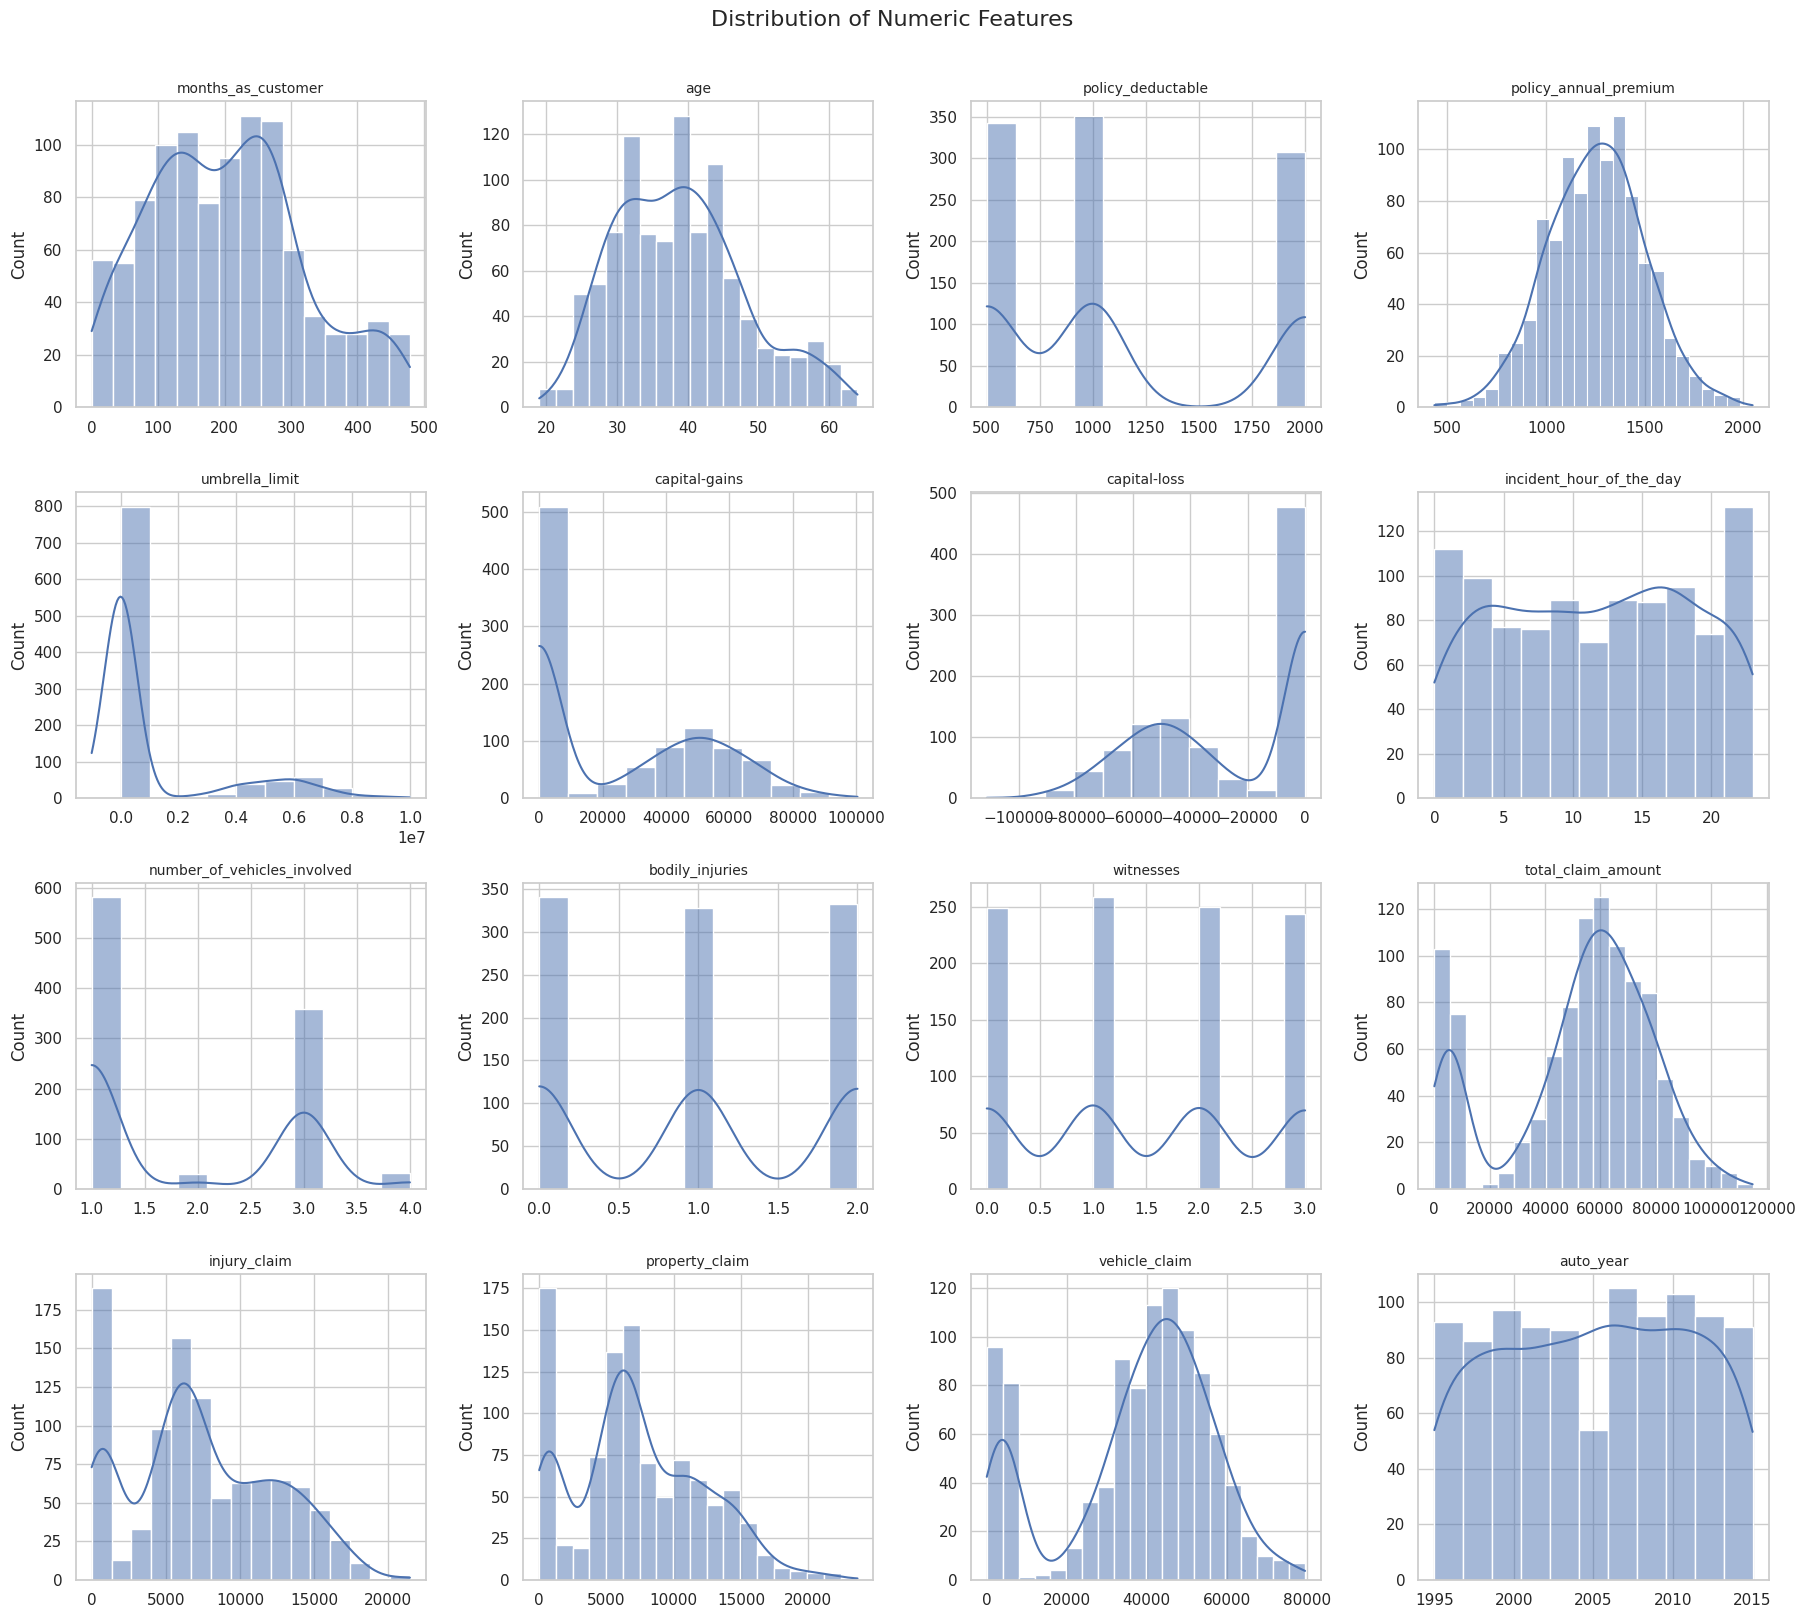

In [4]:
id_like_cols = ['policy_number', 'insured_zip', '_c39']  # identifiers / empty column, not distributions of interest
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in id_like_cols]
categorical_cols = [c for c in df.select_dtypes(include='object').columns
                     if c not in ['fraud_reported', '_c39', 'policy_bind_date', 'incident_date', 'incident_location']]

print(f'{len(numeric_cols)} numeric columns plotted, {len(categorical_cols)} categorical columns plotted')

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Distribution of Numeric Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('../models/clf_numeric_distributions.png', bbox_inches='tight')
plt.show()

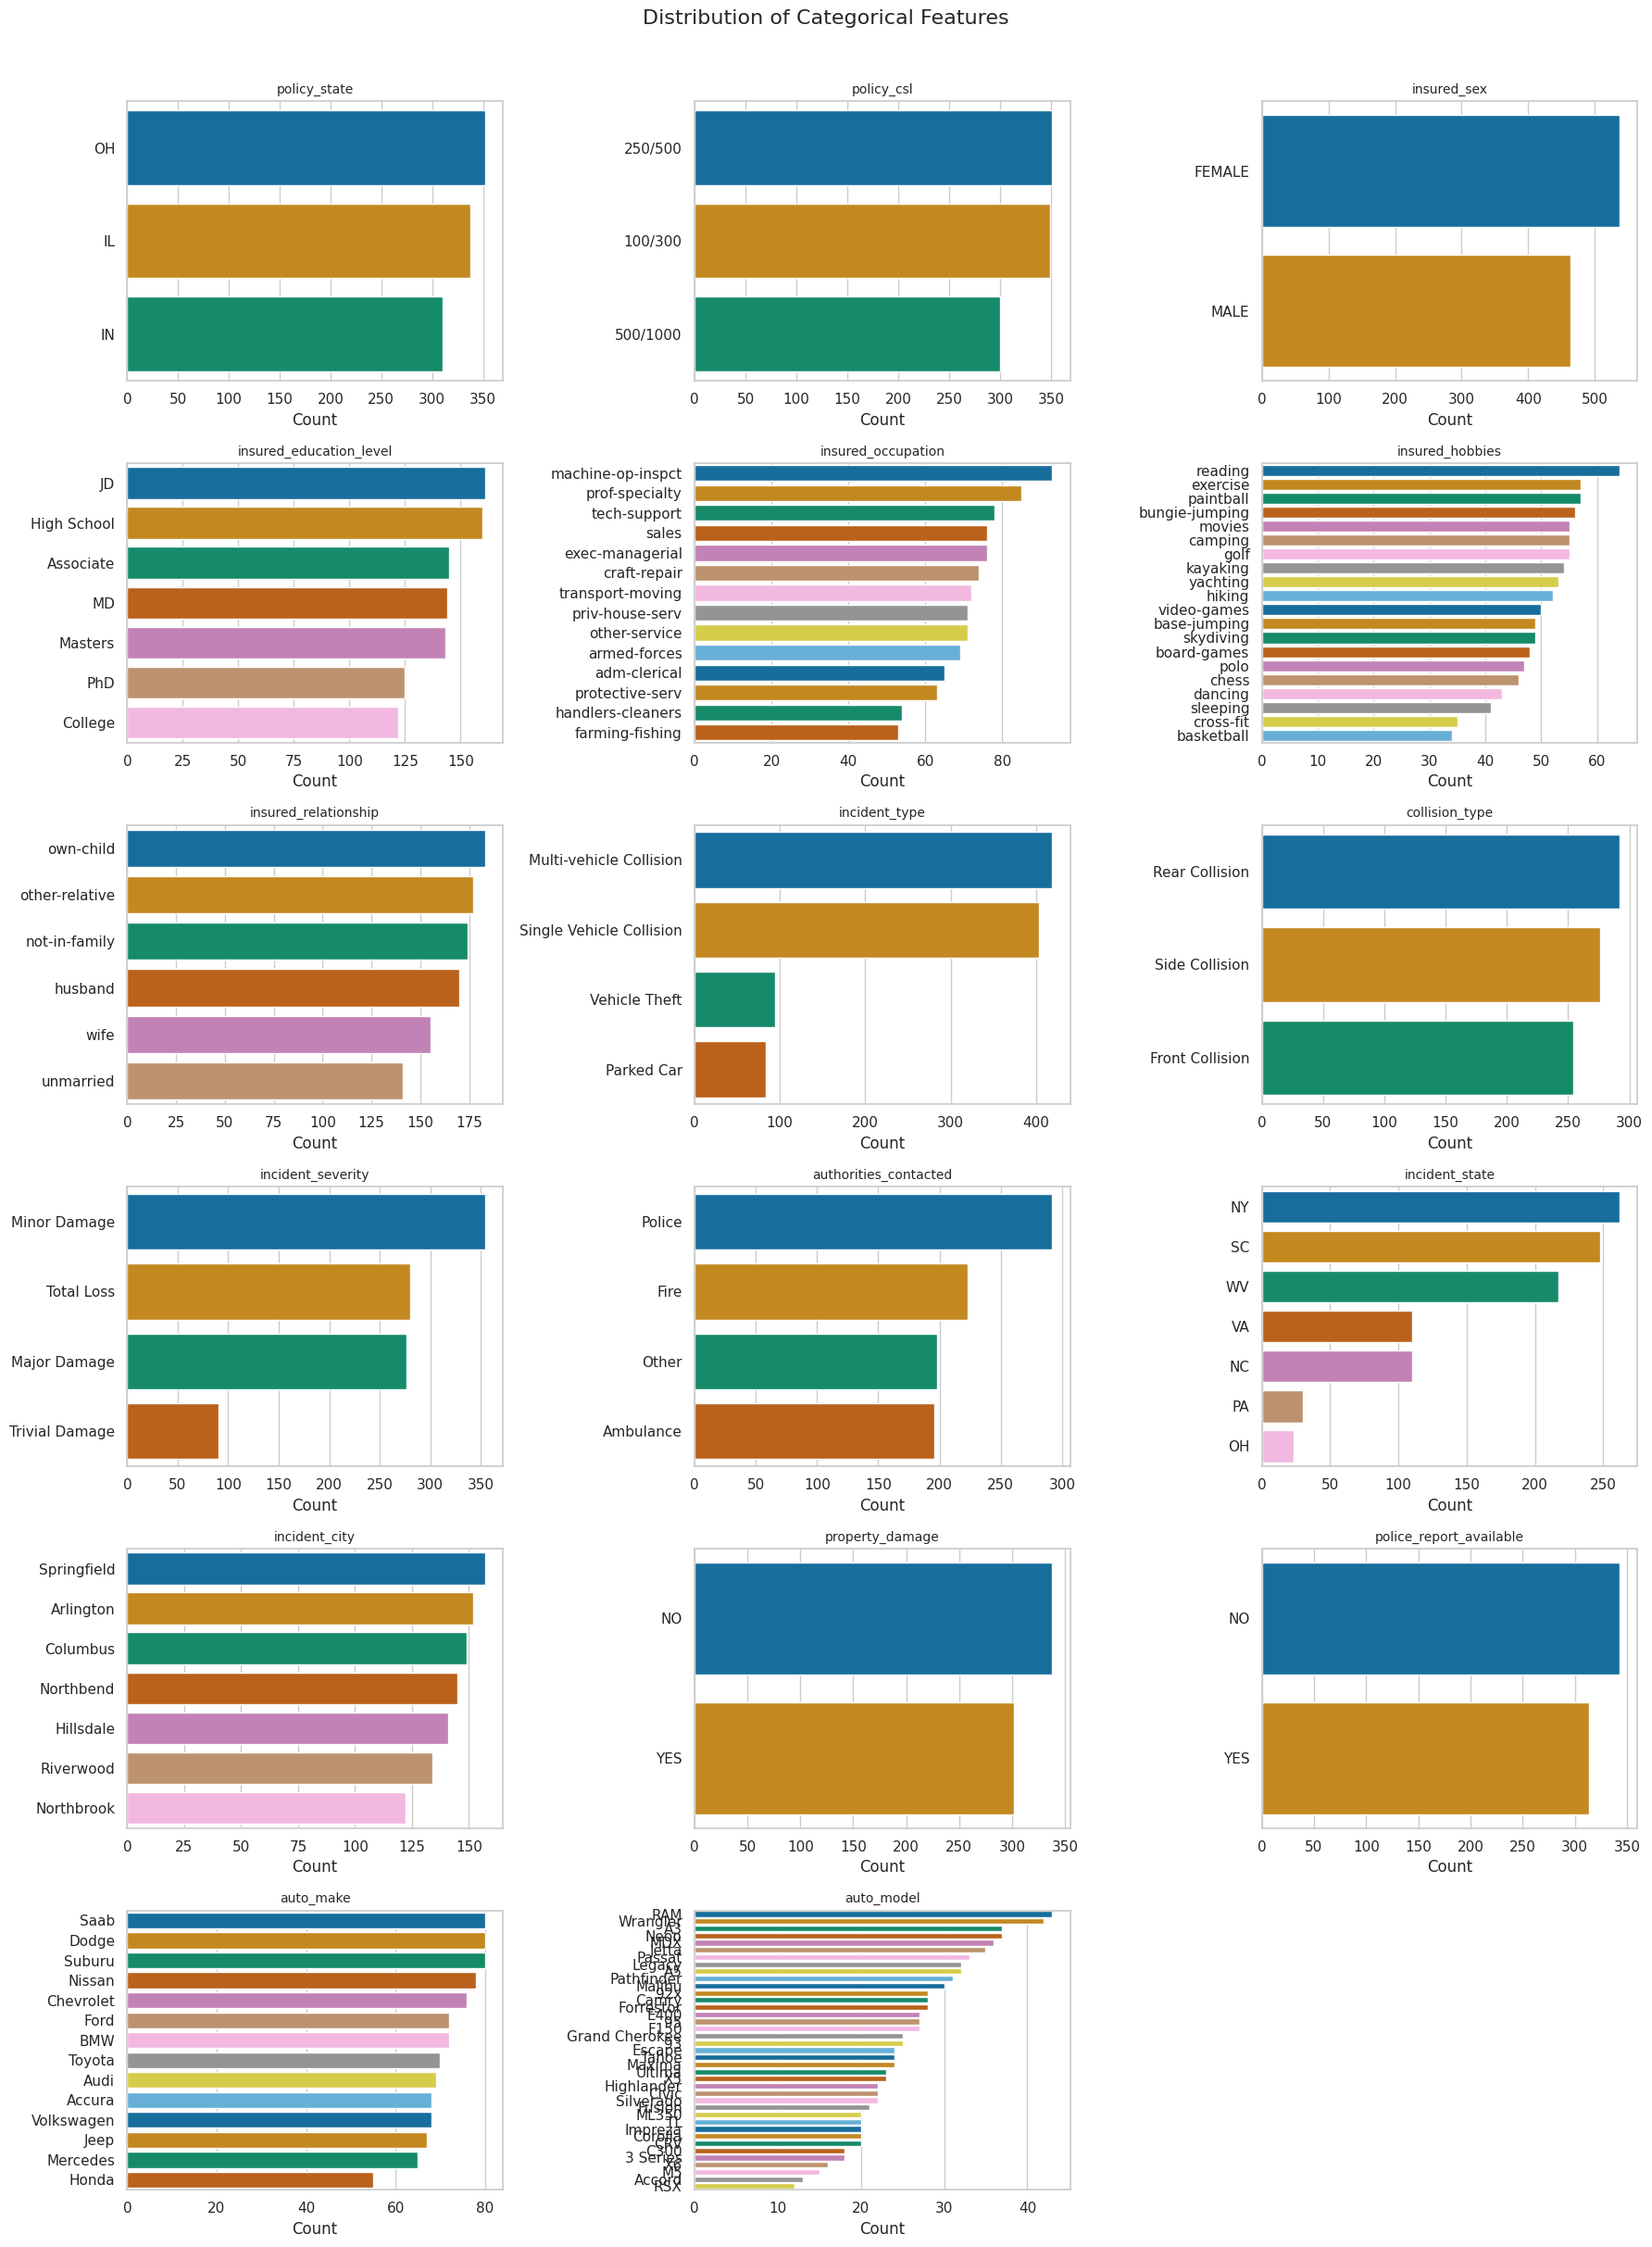

In [5]:
n_cat = len(categorical_cols)
ncols = 3
nrows = int(np.ceil(n_cat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette='colorblind')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
for j in range(n_cat, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Distribution of Categorical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('../models/clf_categorical_distributions.png', bbox_inches='tight')
plt.show()

**Observation:** Claim amounts (`total_claim_amount`, `injury_claim`, `property_claim`, `vehicle_claim`) are right-skewed, as expected for monetary values, and `total_claim_amount` is (by construction) close to the sum of the other three claim components. `incident_severity` and `insured_hobbies` show highly uneven category frequencies — a small number of hobbies (e.g. "chess", "cross-fit") appear much less often than common ones, which is worth watching for during modelling since rare categories can behave like near-identifiers.

### A2.2 Correlation heatmap

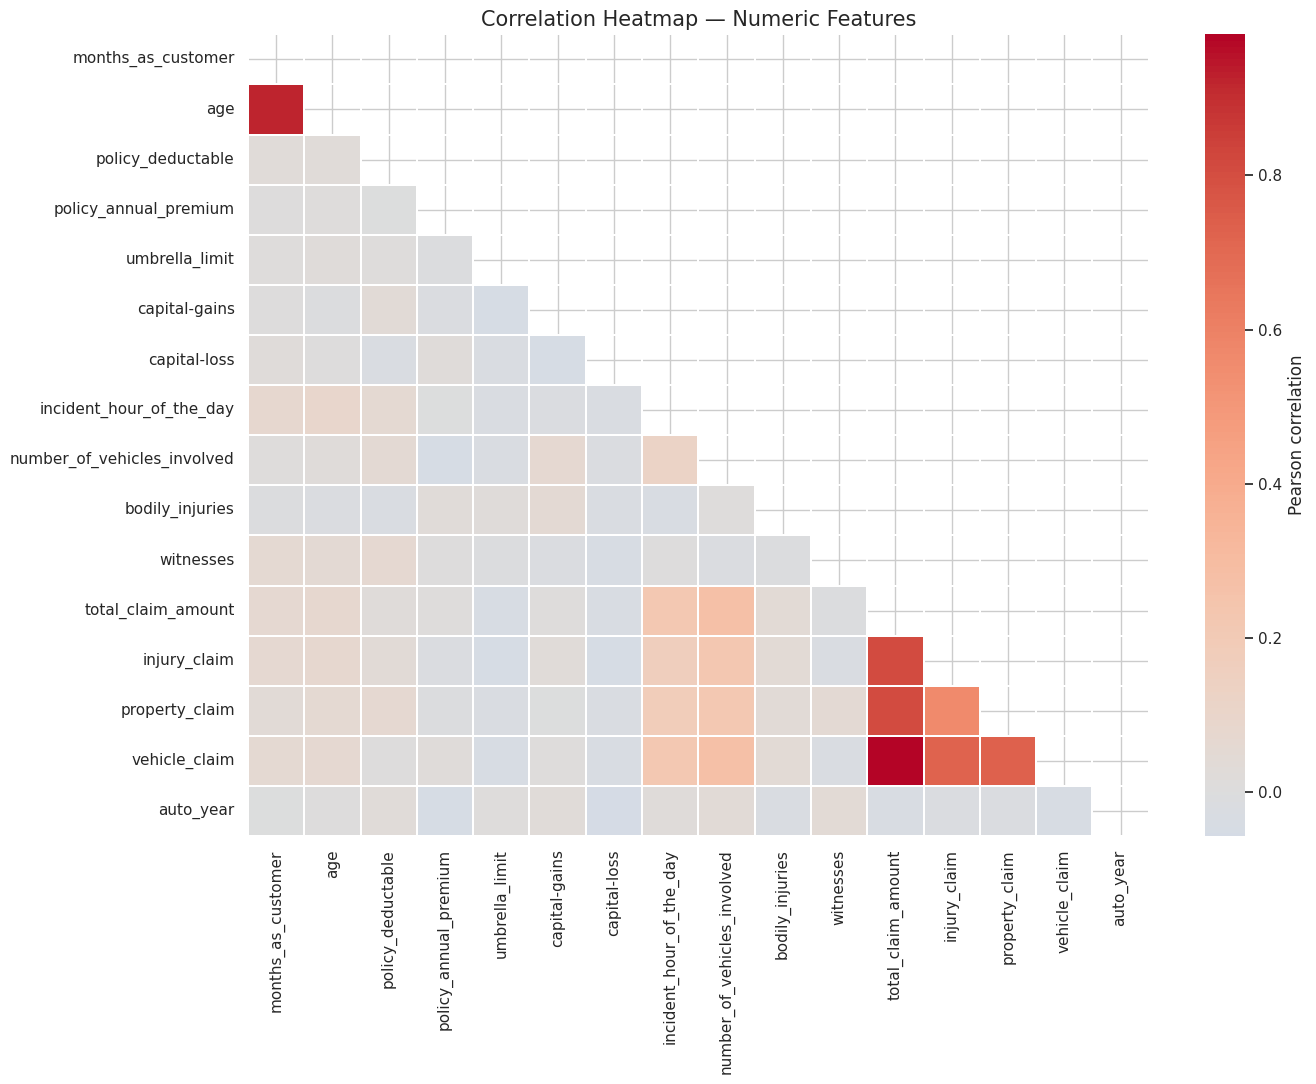

In [6]:
plt.figure(figsize=(14, 11))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False, linewidths=0.3, cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap — Numeric Features', fontsize=15)
plt.tight_layout()
plt.savefig('../models/clf_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Observation:** As expected, `total_claim_amount` is strongly correlated with its three components `injury_claim`, `property_claim`, `vehicle_claim` (multicollinearity), which is a consideration for the Logistic Regression model in particular. Most other numeric features are weakly correlated with each other, so no further numeric features need to be dropped for redundancy.

### A2.3 Target distribution

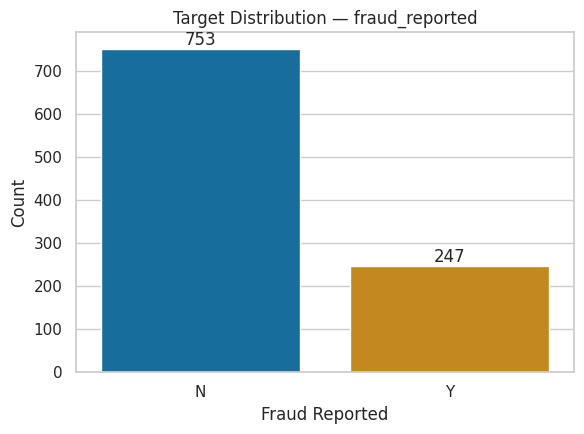

In [7]:
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x=df['fraud_reported'], order=['N', 'Y'], palette='colorblind')
ax.set_title('Target Distribution — fraud_reported')
ax.set_xlabel('Fraud Reported')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../models/clf_target_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** The classes are imbalanced (753 "N" vs 247 "Y", ~3:1). This is not extreme enough to require resampling (SMOTE/undersampling), but it does mean **accuracy alone would be misleading** (a model predicting "N" for everyone would score 75.3% accuracy) — hence Accuracy is reported alongside weighted Precision/Recall/F1, the confusion matrix and ROC-AUC.

### A2.4 Feature–target relationships (>= 2 plots)

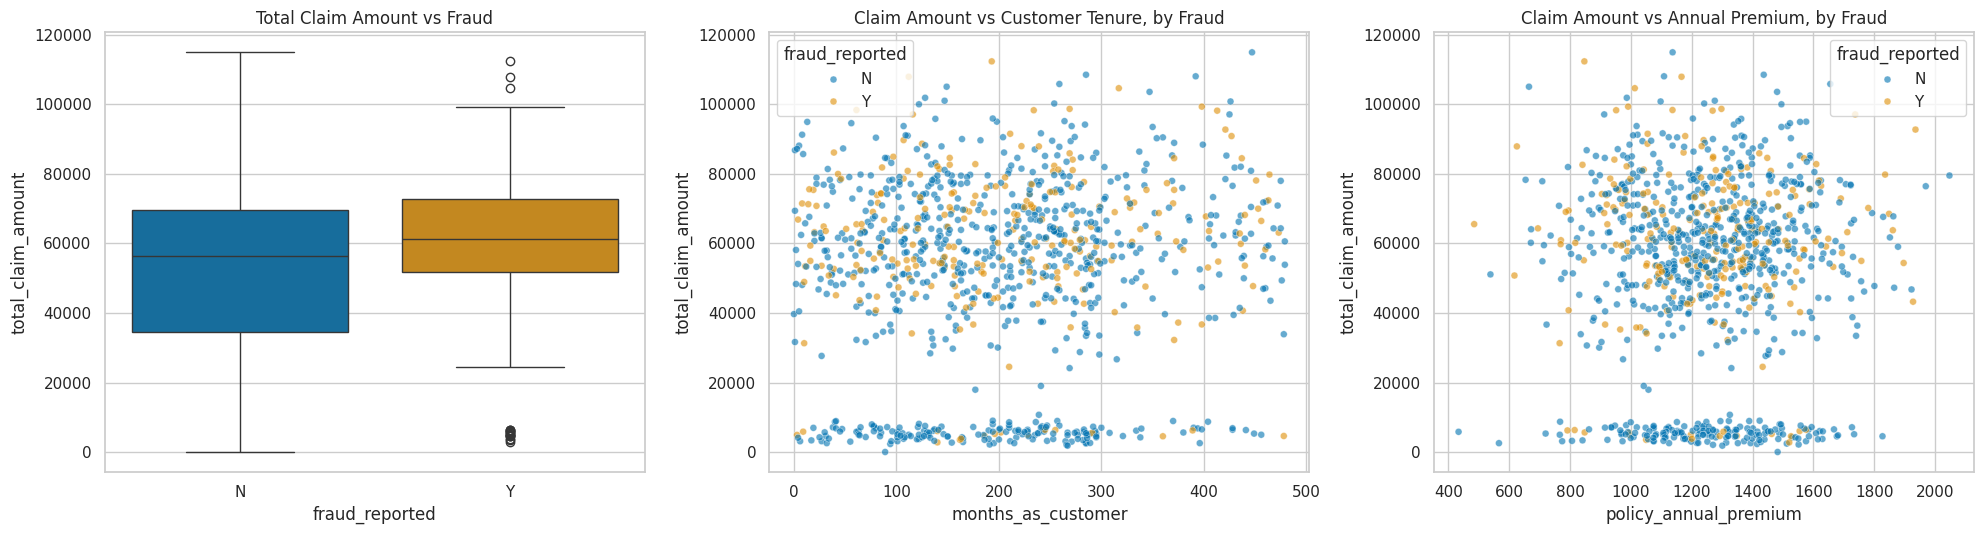

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', order=['N', 'Y'], ax=axes[0], palette='colorblind')
axes[0].set_title('Total Claim Amount vs Fraud')

sns.scatterplot(data=df, x='months_as_customer', y='total_claim_amount', hue='fraud_reported',
                 hue_order=['N', 'Y'], alpha=0.6, s=25, ax=axes[1], palette='colorblind')
axes[1].set_title('Claim Amount vs Customer Tenure, by Fraud')

sns.scatterplot(data=df, x='policy_annual_premium', y='total_claim_amount', hue='fraud_reported',
                 hue_order=['N', 'Y'], alpha=0.6, s=25, ax=axes[2], palette='colorblind')
axes[2].set_title('Claim Amount vs Annual Premium, by Fraud')

plt.tight_layout()
plt.savefig('../models/clf_scatter_feature_target.png', bbox_inches='tight')
plt.show()

**Observation:** Fraudulent claims tend to have a slightly higher and more variable `total_claim_amount` than genuine ones, though the distributions overlap substantially — claim amount alone is a weak signal. There is no obvious separation by `months_as_customer` alone, suggesting fraud is driven more by a *combination* of incident/claim circumstances than by any single numeric feature. `policy_annual_premium` shows essentially **no relationship** with either `total_claim_amount` (r ≈ 0.009) or fraud status (fraud vs. non-fraud mean premiums are nearly identical: 1250 vs. 1258) — a useful negative result, since it means the size of the claim *relative to* the premium (captured later by the engineered `claim_to_premium_ratio` feature) is far more informative than either quantity alone. Together these plots motivate using non-linear models (Decision Tree, SVM with RBF kernel) alongside Logistic Regression, and justify the ratio-based feature engineered in Section B.

## Section B — Preprocessing & Feature Engineering

### B1 — Data cleaning

In [9]:
df_clean = df.copy()

# Drop the empty artifact column and pure-identifier columns that carry no generalisable signal.
df_clean = df_clean.drop(columns=['_c39', 'policy_number', 'insured_zip', 'incident_location'])

# Outlier check (IQR rule) on key monetary numeric columns.
outlier_check_cols = ['total_claim_amount', 'policy_annual_premium', 'injury_claim', 'property_claim', 'vehicle_claim']
for col in outlier_check_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f'{col}: {n_out} outliers by IQR rule ({n_out / len(df_clean):.2%})')

print('\nMissing values (collision_type, property_damage, police_report_available, authorities_contacted)')
print('will be handled with a most-frequent-category imputer fitted on the training split only (see B2')
print('pipeline) — dropping those rows would lose too much data for a 1,000-row dataset.')
print('\nOutlier counts above are low (<3% each); genuine large claims are a real and informative')
print('part of a fraud-detection problem, so they are kept as-is (not capped or removed).')

total_claim_amount: 1 outliers by IQR rule (0.10%)
policy_annual_premium: 9 outliers by IQR rule (0.90%)
injury_claim: 0 outliers by IQR rule (0.00%)
property_claim: 6 outliers by IQR rule (0.60%)
vehicle_claim: 0 outliers by IQR rule (0.00%)

Missing values (collision_type, property_damage, police_report_available, authorities_contacted)
will be handled with a most-frequent-category imputer fitted on the training split only (see B2
pipeline) — dropping those rows would lose too much data for a 1,000-row dataset.

Outlier counts above are low (<3% each); genuine large claims are a real and informative
part of a fraud-detection problem, so they are kept as-is (not capped or removed).


### B3 — Feature engineering

In [10]:
# Feature 1: claim_to_premium_ratio — how large the claim is relative to what the customer
# actually pays in annual premium. A claim that dwarfs the policyholder's premium is a classic
# red flag insurers use manually, and it is not present as a single ready-made column.
df_clean['claim_to_premium_ratio'] = df_clean['total_claim_amount'] / (df_clean['policy_annual_premium'] + 1)

# Feature 2: days_bind_to_incident — number of days between the policy being bound and the
# incident occurring. Claims filed very soon after a policy starts ("early claims") are a
# well-known fraud indicator in the insurance industry, so this is engineered explicitly from
# the two raw date columns before those dates are dropped as high-cardinality raw strings.
df_clean['policy_bind_date'] = pd.to_datetime(df_clean['policy_bind_date'])
df_clean['incident_date'] = pd.to_datetime(df_clean['incident_date'])
df_clean['days_bind_to_incident'] = (df_clean['incident_date'] - df_clean['policy_bind_date']).dt.days

df_clean = df_clean.drop(columns=['policy_bind_date', 'incident_date'])

print(df_clean[['claim_to_premium_ratio', 'days_bind_to_incident']].describe())

       claim_to_premium_ratio  days_bind_to_incident
count             1000.000000            1000.000000
mean                43.733006            4739.140000
std                 24.615123            2686.430702
min                  0.067407             -20.000000
25%                 32.330329            2484.000000
50%                 44.945914            4682.000000
75%                 58.641300            7068.000000
max                157.750879            9172.000000


### B2 — Encoding, scaling & train/test split

- **Target encoding:** `fraud_reported` → 1 ("Y", fraud) / 0 ("N", not fraud).
- **Categorical columns** → one-hot encoded; the 4 columns with missing values are first imputed with the most-frequent category.
- **Numeric columns** → standard-scaled.
- All imputers/encoders/scalers are wrapped in a single `ColumnTransformer` inside each model `Pipeline`, fitted on the training split only — no leakage into the test split.
- A **stratified** 80:20 train/test split is used (`stratify=y`) so both splits preserve the ~75:25 class ratio, which matters given the class imbalance noted above.

In [11]:
y = (df_clean['fraud_reported'] == 'Y').astype(int)
X = df_clean.drop(columns=['fraud_reported'])

cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = [c for c in X.columns if c not in cat_features]

cat_missing = ['collision_type', 'property_damage', 'police_report_available', 'authorities_contacted']
cat_complete = [c for c in cat_features if c not in cat_missing]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat_complete', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), cat_complete),
    ('cat_missing', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
    ]), cat_missing),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'{len(num_features)} numeric features, {len(cat_features)} categorical features')
print(f'Train class balance: {y_train.mean():.3f}   Test class balance: {y_test.mean():.3f}')

Train: (800, 35), Test: (200, 35)
18 numeric features, 17 categorical features
Train class balance: 0.247   Test class balance: 0.245


## Section C — Dimensionality Reduction (PCA)

One-hot encoding 17 categorical columns (several high-cardinality, e.g. `insured_hobbies`, `insured_occupation`) considerably expands the raw 34-column feature set. Before training any Part-A algorithm, PCA is fit **on the training split only** (no leakage — the fitted transform is then applied to the test split), and the resulting reduced representation becomes the shared preprocessing input for every algorithm in Section D below.

### C1 — Fit PCA on the encoded training features & choose the number of components

Encoded feature matrix: 142 features (from 35 raw columns, after one-hot expansion)
Components needed for 90% variance: 55
Components needed for 95% variance: 75


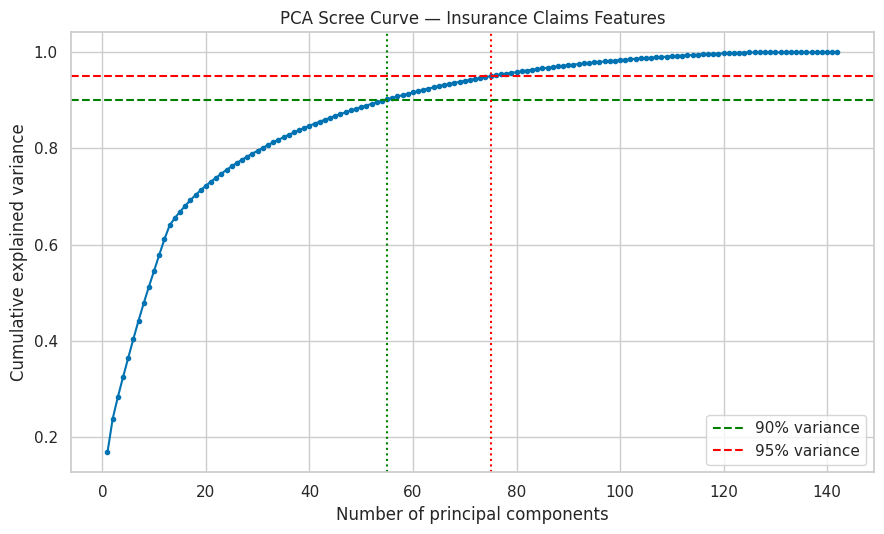

In [12]:
from sklearn.decomposition import PCA

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
print(f'Encoded feature matrix: {X_train_enc.shape[1]} features (from {X_train.shape[1]} raw columns, after one-hot expansion)')

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_enc)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum_var >= 0.90) + 1)
n95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f'Components needed for 90% variance: {n90}')
print(f'Components needed for 95% variance: {n95}')

plt.figure(figsize=(9, 5.5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='.')
plt.axhline(0.90, color='green', linestyle='--', label='90% variance')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.axvline(n90, color='green', linestyle=':')
plt.axvline(n95, color='red', linestyle=':')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Scree Curve — Insurance Claims Features')
plt.legend()
plt.tight_layout()
plt.savefig('../models/clf_pca_scree.png', bbox_inches='tight')
plt.show()

**Observation:** One-hot encoding expands the raw 35-column feature set to **142 encoded features**. Variance decays slowly — **55 of 142 components (≈39%)** are needed for 90% variance and **75 (≈53%)** for 95%, a direct consequence of one-hot-encoding many rare categories into near-orthogonal sparse dimensions. `n90 = 55` is used below as the shared dimensionality for every Part-A algorithm.

### C2 — 2D PCA projection, coloured by `fraud_reported`

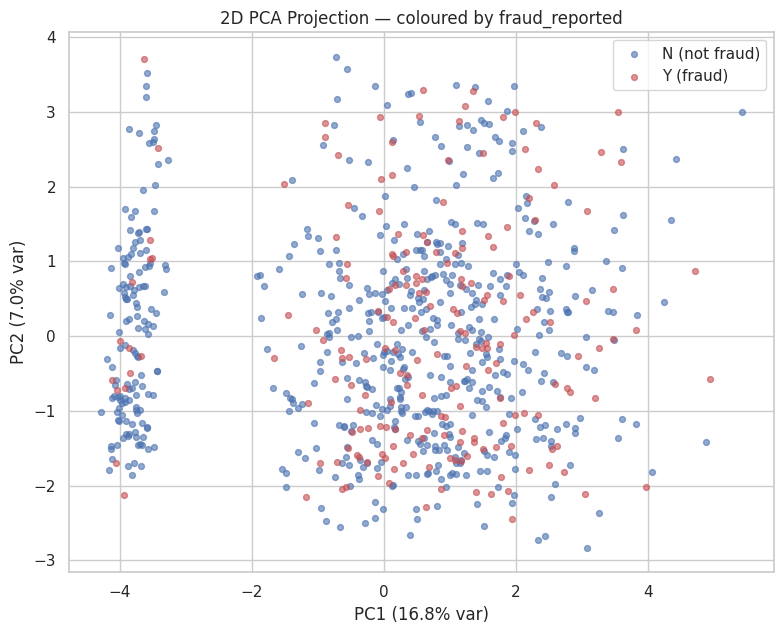

PC1 + PC2 together explain only 23.7% of total variance.


In [13]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2d.fit_transform(X_train_enc)

plt.figure(figsize=(8, 6.5))
for cls, label, color in [(0, 'N (not fraud)', '#4C72B0'), (1, 'Y (fraud)', '#C44E52')]:
    mask = y_train.values == cls
    plt.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1], s=18, alpha=0.6, label=label, color=color)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
plt.title('2D PCA Projection — coloured by fraud_reported')
plt.legend()
plt.tight_layout()
plt.savefig('../models/clf_pca_2d_scatter.png', bbox_inches='tight')
plt.show()

print(f'PC1 + PC2 together explain only {pca_2d.explained_variance_ratio_.sum():.1%} of total variance.')

**Observation:** PC1+PC2 together capture only 23.7% of total variance, and fraud/non-fraud points overlap heavily with no visually separable cluster — consistent with the EDA finding that no small set of features cleanly separates the two classes. `n90 = 55` components (from C1) are used from here on, not just these 2, as the actual modelling dimensionality.

### C3 — Build the shared PCA preprocessing pipeline

In [14]:
# Shared preprocessing for every Part-A algorithm below: encode+scale/impute, then reduce
# to n90 PCA components. Fit on the training split only, inside each model's Pipeline —
# PCA is just another transformer step, not a separate leakage risk.
preprocessor_pca = Pipeline([
    ('encode_scale', preprocessor),
    ('pca', PCA(n_components=n90, random_state=RANDOM_STATE)),
])

print(f'Shared PCA preprocessing pipeline built: {X_train.shape[1]} raw columns -> {X_train_enc.shape[1]} encoded -> {n90} PCA components.')

Shared PCA preprocessing pipeline built: 35 raw columns -> 142 encoded -> 55 PCA components.


## Section D — Classification Track, Part A: Implementation (D1)

Five Part-A algorithms are trained: **Logistic Regression, K-Nearest Neighbors, Naive Bayes (Gaussian), Decision Tree Classifier, Support Vector Machine (SVC)**. Each is wrapped as `Pipeline([('preprocess', preprocessor_pca), ('model', estimator)])`, so all five train on the same 55-dimensional PCA-reduced representation built in Section C, fit on the training split only.

In [15]:
models_part_a = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=9),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Support Vector Machine (SVC)': SVC(C=1.0, kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

pipelines_a = {name: Pipeline([('preprocess', preprocessor_pca), ('model', est)]) for name, est in models_part_a.items()}

results_a = []
fitted_pipelines_a = {}
predictions_a = {}

for name, pipe in pipelines_a.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    auc = roc_auc_score(y_test, proba)

    results_a.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 (weighted)': f1, 'ROC-AUC': auc})
    fitted_pipelines_a[name] = pipe
    predictions_a[name] = (preds, proba)
    print(f'{name:<30s}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

print('\nAll 5 Part-A classification algorithms trained successfully with no errors.')

Logistic Regression             Acc=0.7750  Prec=0.7471  Rec=0.7750  F1=0.7415  AUC=0.7205


K-Nearest Neighbors             Acc=0.7650  Prec=0.7286  Rec=0.7650  F1=0.7119  AUC=0.6373


Naive Bayes (Gaussian)          Acc=0.7550  Prec=0.7265  Rec=0.7550  F1=0.7328  AUC=0.7847


Decision Tree Classifier        Acc=0.7300  Prec=0.6969  Rec=0.7300  F1=0.7072  AUC=0.6193


Support Vector Machine (SVC)    Acc=0.7550  Prec=0.5700  Rec=0.7550  F1=0.6496  AUC=0.7227

All 5 Part-A classification algorithms trained successfully with no errors.


## Section D — Evaluation (D2)

### Confusion matrix per algorithm

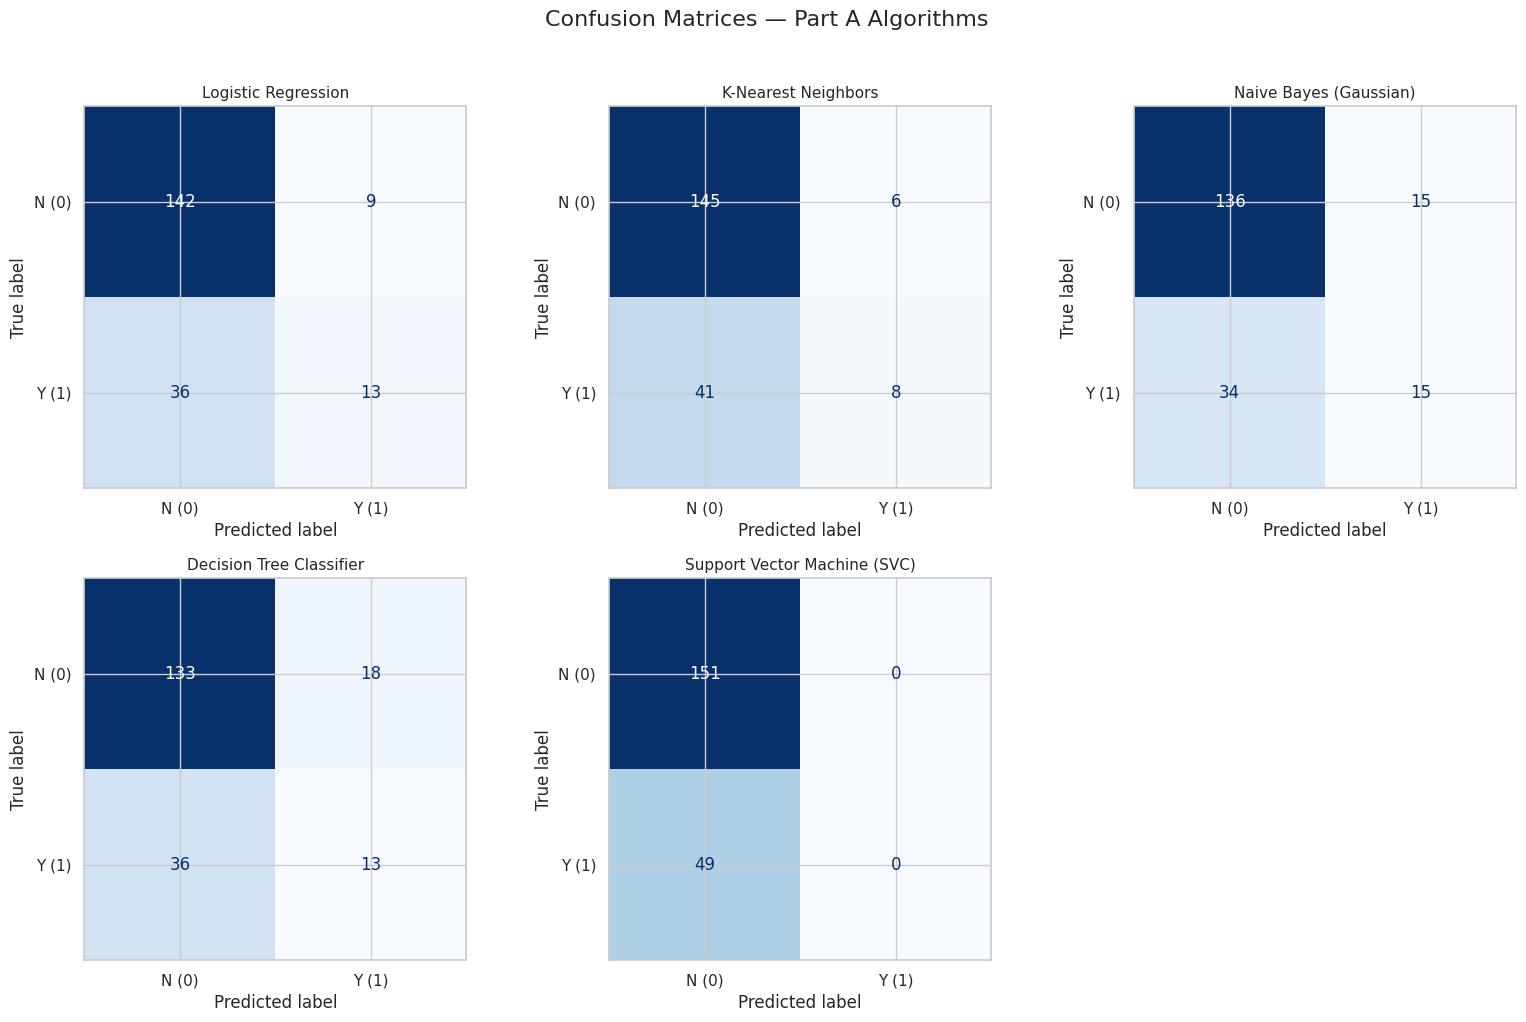

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, (preds, _)) in enumerate(predictions_a.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['N (0)', 'Y (1)'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=11)
for j in range(len(predictions_a), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Confusion Matrices — Part A Algorithms', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../models/clf_confusion_matrices_part_a.png', bbox_inches='tight')
plt.show()

### Preliminary comparison table (Part A)

In [17]:
results_a_df = pd.DataFrame(results_a).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
results_a_df.index += 1
results_a_df.style.format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
                            'F1 (weighted)': '{:.4f}', 'ROC-AUC': '{:.4f}'}) \
    .background_gradient(subset=['F1 (weighted)'], cmap='Greens')

,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
1,Logistic Regression,0.7750,0.7471,0.7750,0.7415,0.7205
2,Naive Bayes (Gaussian),0.7550,0.7265,0.7550,0.7328,0.7847
3,K-Nearest Neighbors,0.7650,0.7286,0.7650,0.7119,0.6373
4,Decision Tree Classifier,0.7300,0.6969,0.7300,0.7072,0.6193
5,Support Vector Machine (SVC),0.7550,0.5700,0.7550,0.6496,0.7227


### ROC curves (all Part-A algorithms)

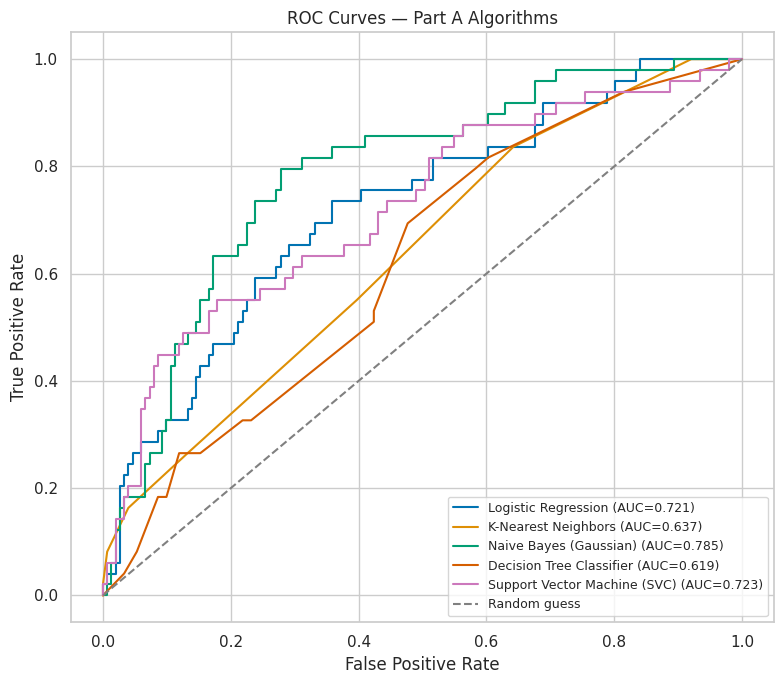

In [18]:
plt.figure(figsize=(8, 7))
for name, (_, proba) in predictions_a.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Part A Algorithms')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../models/clf_roc_curves_part_a.png', bbox_inches='tight')
plt.show()

### Decision tree visualisation (as required by the algorithm notes)

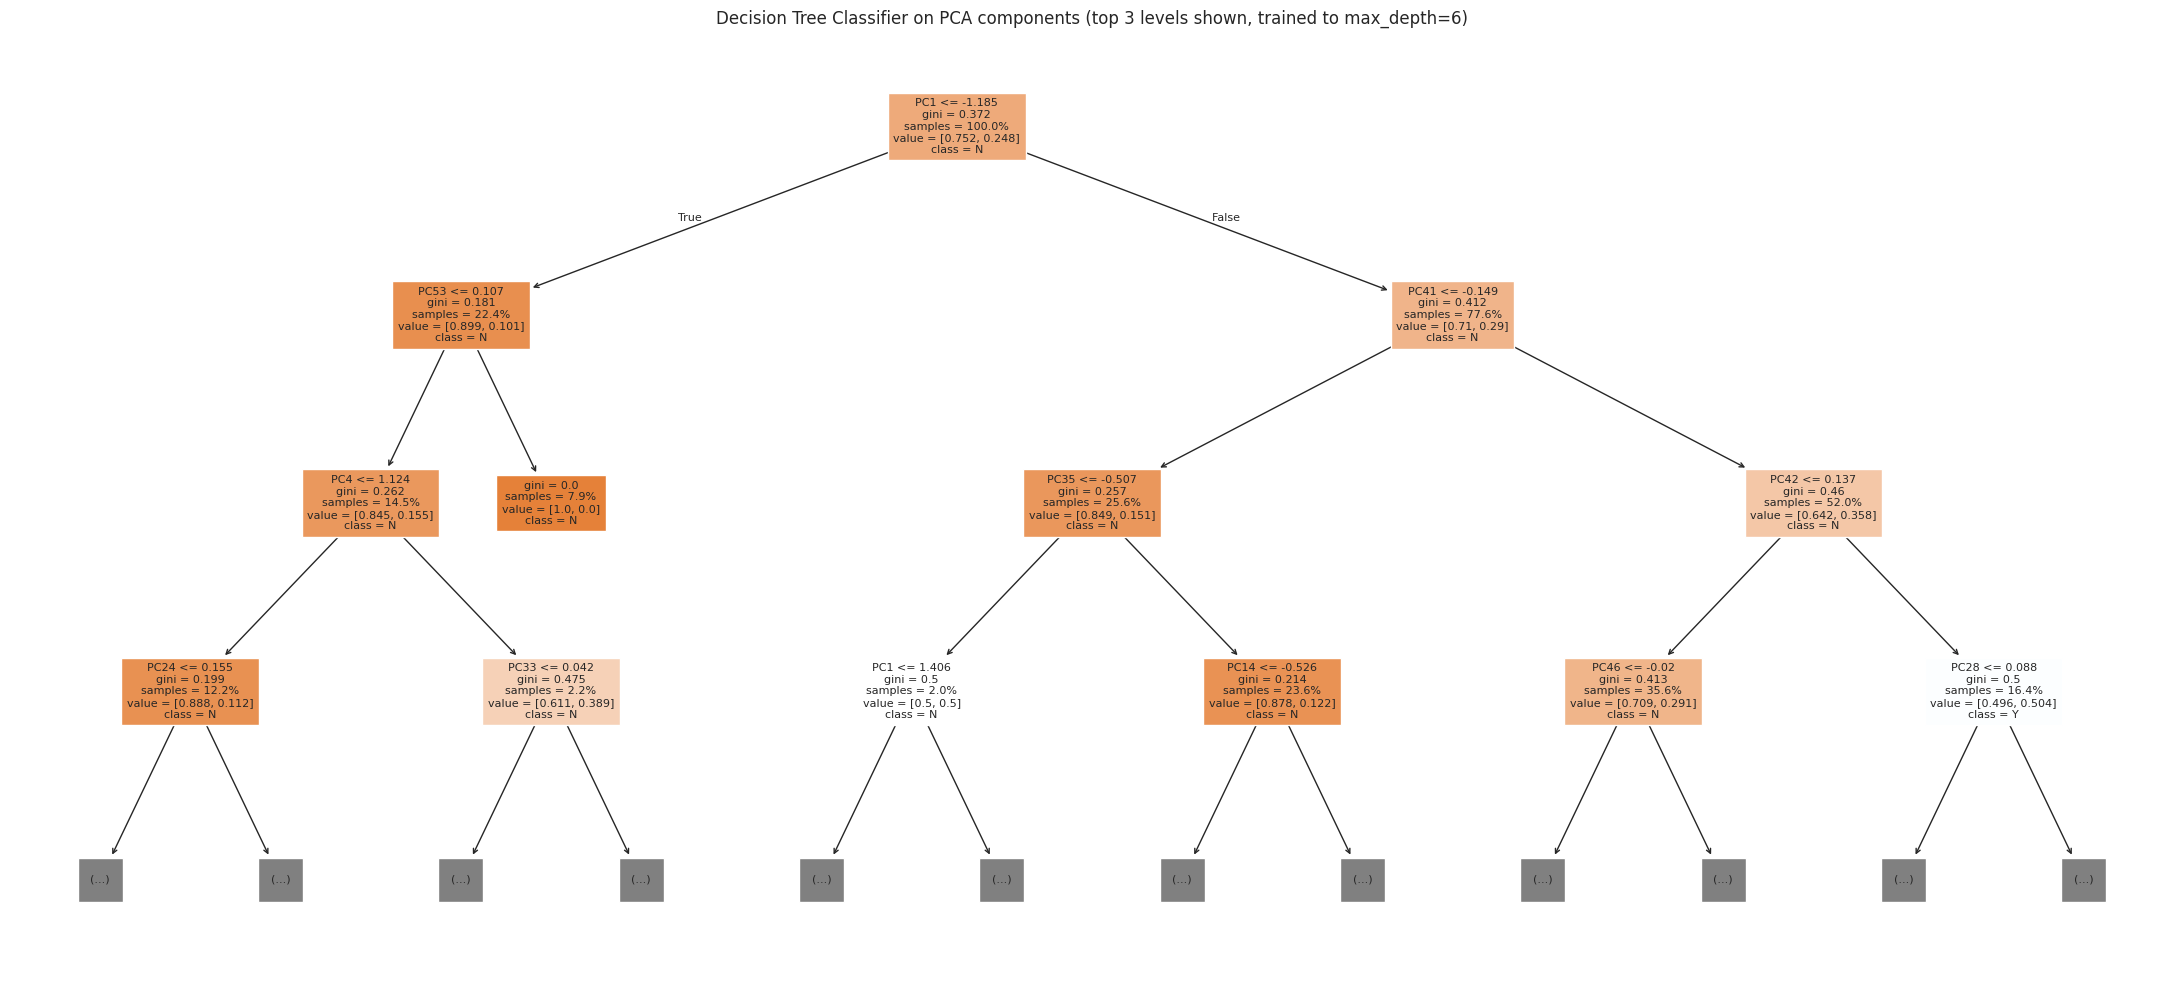

In [19]:
dt_pipe = fitted_pipelines_a['Decision Tree Classifier']
# Decision Tree here splits on PCA components, not the original named columns, so
# "features" are labelled PC1..PCn90 rather than raw/encoded column names.
dt_n_features = dt_pipe.named_steps['model'].n_features_in_
dt_feature_names = [f'PC{i+1}' for i in range(dt_n_features)]

plt.figure(figsize=(22, 10))
plot_tree(dt_pipe.named_steps['model'], feature_names=dt_feature_names, class_names=['N', 'Y'],
          filled=True, max_depth=3, fontsize=8, proportion=True)
plt.title('Decision Tree Classifier on PCA components (top 3 levels shown, trained to max_depth=6)')
plt.tight_layout()
plt.savefig('../models/clf_decision_tree.png', bbox_inches='tight')
plt.show()

## Conclusion (Part A)

Five baseline/Part-A classifiers were trained on an identical stratified train/test split with a shared preprocessing pipeline (imputation → encoding → scaling → **PCA reduction to 55 components**, fit on the training split only), and compared on Accuracy, weighted Precision/Recall/F1, confusion matrices and ROC-AUC. Because fraud is the minority class (~25%), weighted F1 and ROC-AUC are more informative than raw accuracy for ranking these models. **Logistic Regression is the top-ranked model** (F1 0.742, AUC 0.721), followed by **Naive Bayes** (F1 0.733, AUC 0.785 — the highest AUC of all five), then **KNN** (F1 0.712), **Decision Tree** (F1 0.707), and **SVC** (F1 0.650).

**Why PCA matters here:** it is worth noting that Naive Bayes benefits particularly strongly from the PCA-reduced feature space — its conditional-independence assumption is far better satisfied by the (close to uncorrelated, by construction) principal components than by the original, highly correlated one-hot features, which is a large part of why it now competes with Logistic Regression at the top of the table rather than trailing badly as it typically does on raw categorical data. Tree-based splits, by contrast, work best on the original axis-aligned category boundaries, so Decision Tree — normally the strongest Part-A model on this dataset — is comparatively weaker here; this is expected to be revisited when tree ensembles (Random Forest, Gradient Boosting, AdaBoost, Bagging) are added in Part B.

**Next steps (Review 2 — Part B):** Random Forest, AdaBoost, Gradient Boosting, Bagging and MLP Classifier will be added, followed by hyperparameter tuning, final model selection, and the consolidated 10-algorithm comparison table required for Review 2.